# Rossman Store Sales: EDA

In this notebook, we try explore the Rossmann data and try to find some insights
before jumping into processing the data.

The found **insights** are listed at the end of the notebook.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys

# Add the parent directory (project root) to sys.path if not already there
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [4]:
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.display_functions import display

warnings.filterwarnings("ignore")

## Load datasets

In [5]:
DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}/train.csv", parse_dates=["Date"])
store = pd.read_csv(f"{DATA_PATH}/store.csv")

train = train.merge(store, on="Store")

print("Train dataset:")
display(train.head())
display(f"Train size: {train.shape}")

Train dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


'Train size: (1017209, 18)'

## Preprocessing

For some checks, we might have to preprocess the data.

In [152]:
train["year"] = train["Date"].dt.year
train["month"] = train["Date"].dt.month

# Check the difference between competitor and Rossmann store
# Negative values mean Rossmann store opened a store before its the competitor
train["days_to_competitor"] = (train["Date"] - pd.to_datetime(train["CompetitionOpenSinceYear"], format="%Y")).dt.days

## Exploration

Before building any Machine Learning model, we have to explore the data
so that we can better understand it.

In [5]:
# How many stores and number of records?
num_stores = train.groupby("Store")["Sales"].count().to_frame("num_records")
num_stores.describe()

,num_records
count,1115.000000
mean,912.295067
std,67.729422
min,758.000000
25%,942.000000
50%,942.000000
75%,942.000000
max,942.000000


In [6]:
# What's the Sales look like when the Stores are open?
open_sales = train[train["Open"] == 1]

open_sales[["Sales"]].describe().round(2)

,Sales
count,844392.00
mean,6955.51
std,3104.21
min,0.00
25%,4859.00
50%,6369.00
75%,8360.00
max,41551.00


In [7]:
# What's the Sales look like when the Stores are open?
open_sales_desc = open_sales.groupby("Store")["Sales"].describe()
open_sales_desc.round(2).sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Store,,,,,,,,
817,784.0,21757.48,4674.80,6052.0,19154.75,21872.0,24663.25,38025.0
262,942.0,20718.52,4668.88,13210.0,17454.25,19415.5,22125.00,38722.0
1114,784.0,20666.56,3452.94,8880.0,18366.50,20412.5,22350.00,35697.0
251,779.0,19123.07,3547.64,8373.0,16536.50,18566.0,21033.00,35350.0
842,622.0,18574.80,3788.99,7769.0,15908.00,18330.0,20665.25,35154.0
...,...,...,...,...,...,...,...,...
841,780.0,2972.61,1096.26,958.0,2302.25,2907.0,3625.75,7020.0
208,784.0,2936.29,716.53,1546.0,2405.75,2927.5,3358.75,5864.0
198,782.0,2900.60,1597.76,530.0,1769.75,2526.0,3756.75,10676.0


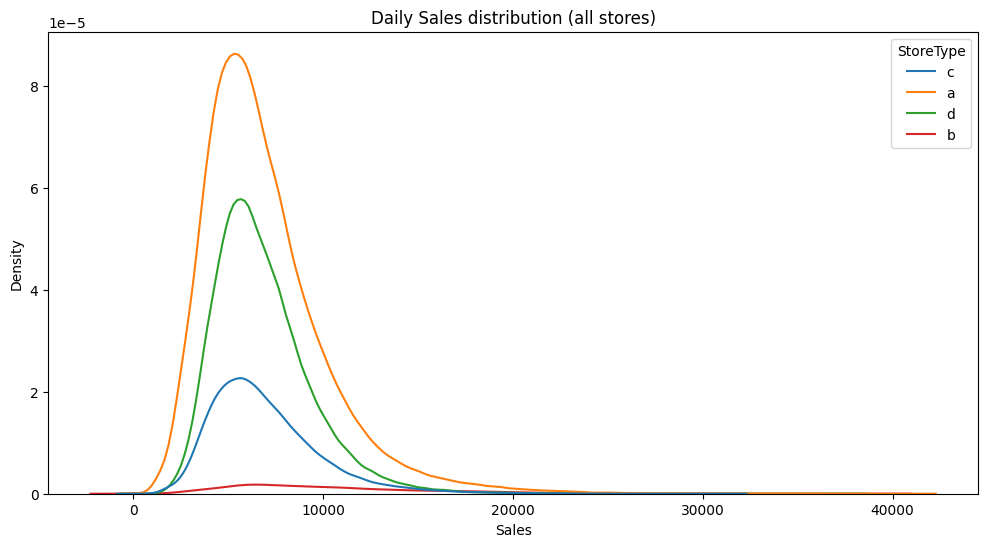

In [8]:
fig, ax = plt.subplots(figsize=(12,6))
sns.kdeplot(data=open_sales, x="Sales", hue="StoreType")
ax.set(title="Daily Sales distribution (all stores)");

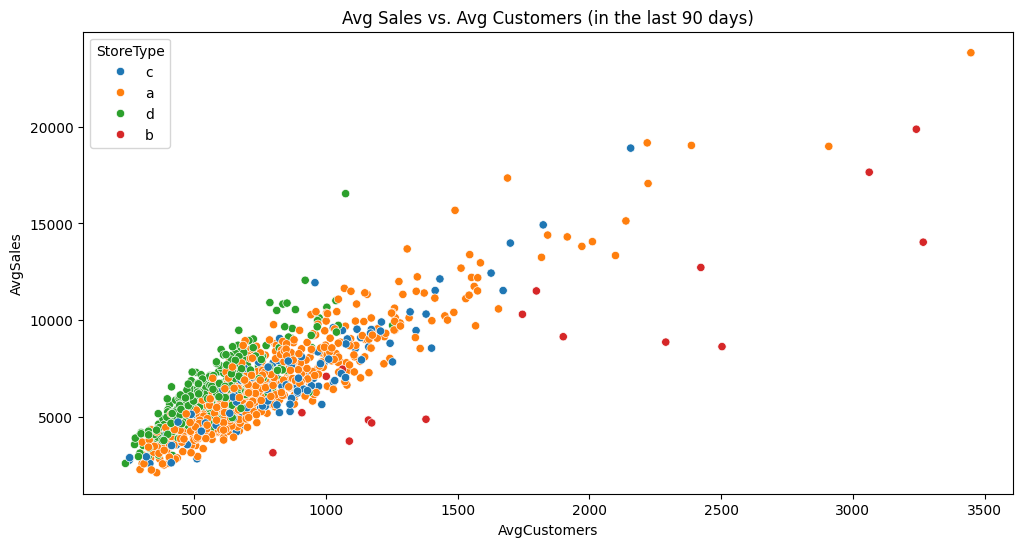

In [18]:
# Checking the avg. sales vs avg. customer (in the last 90 days)
last90days_sales = open_sales.groupby("Store").tail(90).sort_values(
    ["Store", "Date"])

sales_last90d = last90days_sales.groupby("Store").agg({
    "Sales": "mean",
    "Customers": "mean",
    "StoreType": "max"
}).round(3)

sales_last90d.reset_index(inplace=True)

sales_last90d.rename(columns={
    "Sales": "AvgSales",
    "Customers": "AvgCustomers"
}, inplace=True)

fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(
    data=sales_last90d,
    x="AvgCustomers",
    y="AvgSales",
    hue="StoreType",
    ax=ax
)
ax.set(title="Avg Sales vs. Avg Customers (in the last 90 days)");


In [16]:
# What's the Number of customers look like when the Stores are open?
open_customers_desc = open_sales.groupby("Store")["Customers"].describe()
open_customers_desc.round(2).sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
Store,,,,,,,,
733,942.0,3403.46,338.49,1329.0,3209.00,3393.0,3586.75,4645.0
262,942.0,3402.01,580.75,2255.0,3000.00,3239.0,3600.75,5494.0
1114,784.0,3200.95,441.87,1160.0,2907.75,3179.5,3467.25,4911.0
817,784.0,3130.57,597.36,738.0,2855.75,3182.0,3489.00,7388.0
562,942.0,3105.05,330.30,1663.0,2914.25,3127.0,3314.75,4099.0
...,...,...,...,...,...,...,...,...
1068,777.0,309.54,61.57,154.0,266.00,303.0,346.00,644.0
307,782.0,307.81,91.80,104.0,254.25,313.0,373.00,669.0
232,766.0,303.84,72.42,0.0,255.00,296.5,345.00,868.0


In [11]:
# Check sales by StoreType
open_sales.groupby("StoreType")["Sales"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457077.0,6925.17,3277.79,0.0,4695.0,6285.0,8406.0,41551.0
b,15563.0,10231.41,5157.19,0.0,6344.0,9130.0,13183.5,38722.0
c,112978.0,6932.51,2897.56,0.0,4915.0,6407.0,8349.0,31448.0
d,258774.0,6822.14,2556.58,0.0,5050.0,6395.0,8123.0,38037.0


In [ ]:
# Check num. customers by StoreType
open_sales.groupby("StoreType")["Customers"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457077.0,795.36,387.56,0.0,547.0,720.0,949.0,7388.0
b,15563.0,2021.82,911.03,0.0,1255.0,1839.0,2750.5,5494.0
c,112978.0,815.47,329.74,0.0,583.0,756.0,981.0,3096.0
d,258774.0,606.34,199.27,0.0,464.0,577.0,716.0,2239.0


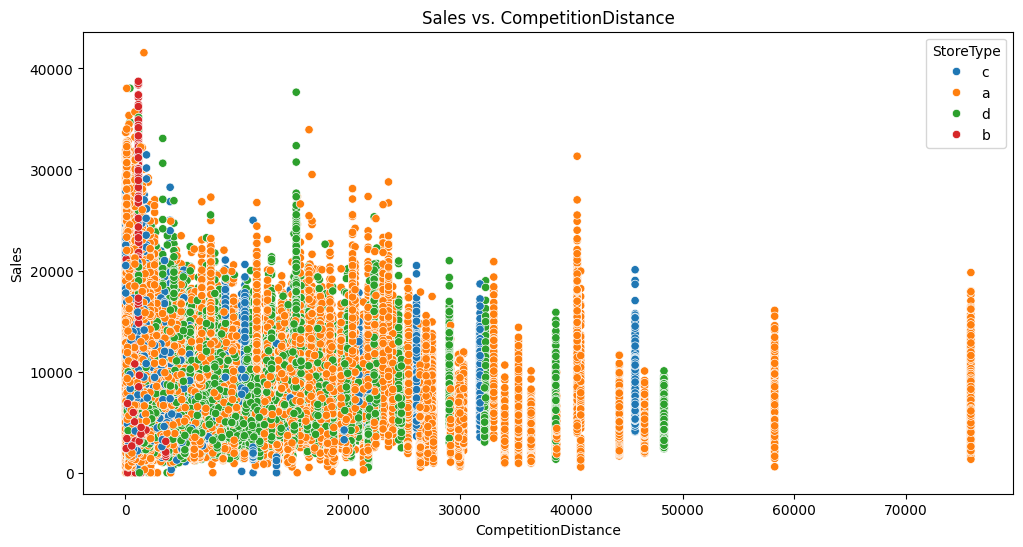

In [17]:
# Check CompetitionDistance vs Sales to see if there's any direct impact on Sales when CompetitionDistance is close to the Store

fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data=open_sales, x="CompetitionDistance", y="Sales", hue="StoreType")
ax.set(title="Sales vs. CompetitionDistance");

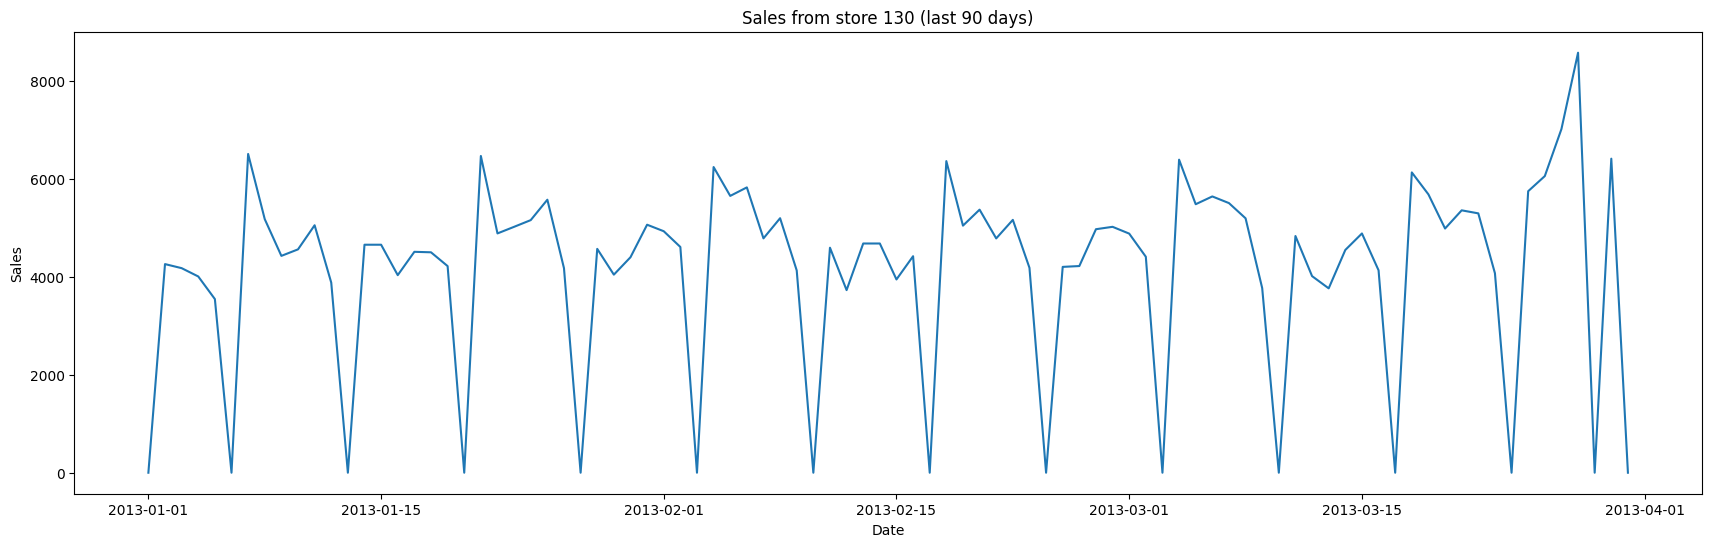

In [24]:
# Let's pick a random store and see how the sales are...
store_id = int(random.choice(open_sales["Store"].unique()))

store_data = train[train["Store"] == store_id].copy()
store_data.sort_values("Date", inplace=True)

fig, ax = plt.subplots(figsize=(21,6))
sns.lineplot(data=store_data[:90], x="Date", y="Sales")
ax.set(title=f"Sales from store {store_id} (last 90 days)");

In [62]:
# Checking found peaks in a selected store

#store_data[store_data["Sales"] > 17000]
#store_data[store_data["Date"] <= "2013-12-31"].tail(12)

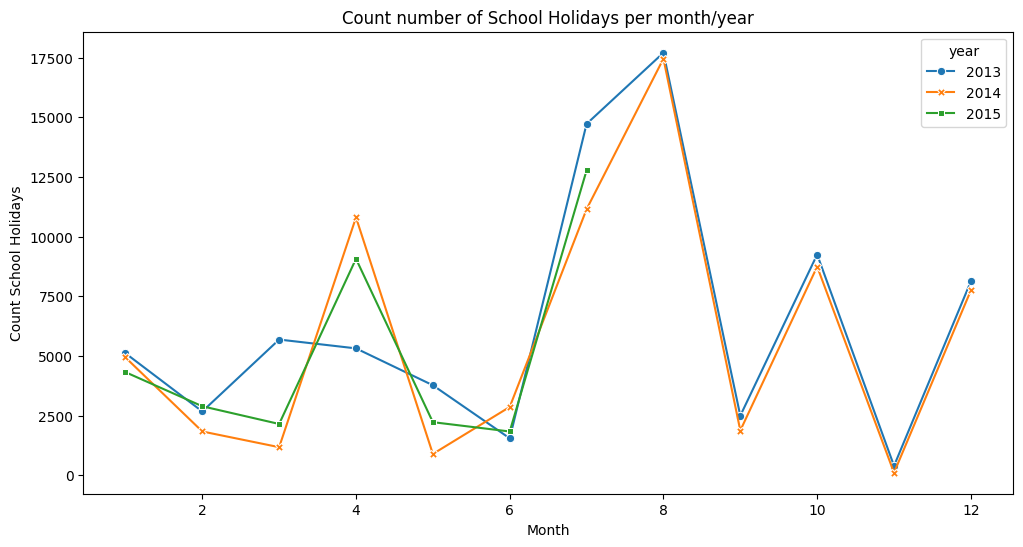

In [82]:
# What is the number of School Holiday per month/year?
schoolholidays_year = train[train["SchoolHoliday"] == 1].groupby(
    ["year", "month"]
)["SchoolHoliday"].count().to_frame("count_SchoolHoliday")
schoolholidays_year.reset_index(inplace=True)

fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(
    data=schoolholidays_year,
    x="month",
    y="count_SchoolHoliday",
    hue="year",
    palette="tab10",
    style="year",
    markers=True, dashes=False,
    ax=ax
)
ax.set(title="Count number of School Holidays per month/year",
        xlabel="Month", ylabel="Count School Holidays");


In [62]:
# How does Sales look like based on Assortment?
train.groupby("Assortment")["Sales"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
Assortment,,,,,,,,
a,537445.0,5481.026,3682.766,0.0,3492.0,5463.0,7514.00,38722.0
b,8294.0,8553.932,3882.418,0.0,5523.0,8026.5,11233.25,22137.0
c,471470.0,6058.677,3992.256,0.0,4017.0,6039.0,8184.00,41551.0


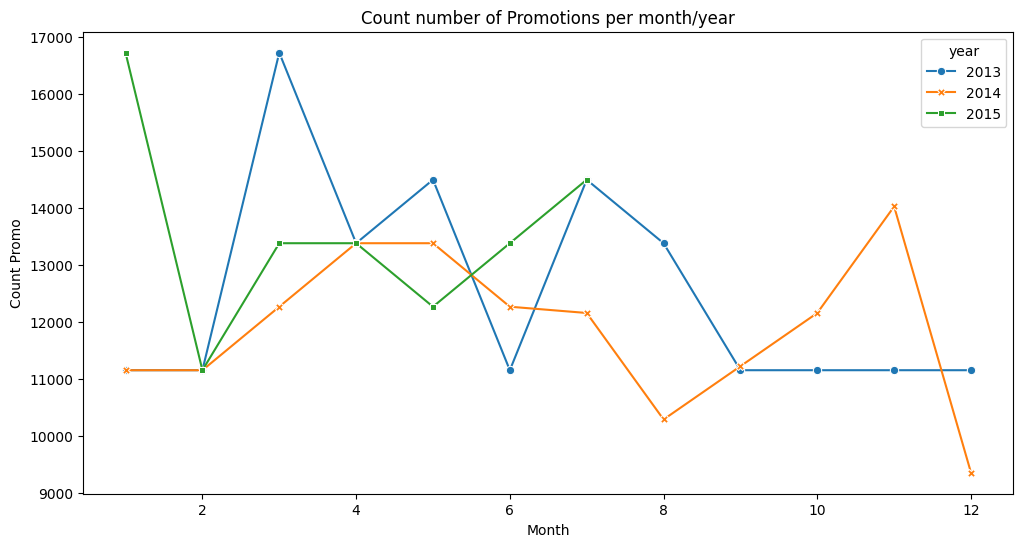

In [ ]:
# Check on the number of Promos by year/month

count_promos = train[train["Promo"] == 1].groupby(["year","month"])["Promo"].count().to_frame("count_Promo")
count_promos.reset_index(inplace=True)

fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(
    data=count_promos,
    x="month",
    y="count_Promo",
    hue="year",
    palette="tab10",
    style="year",
    markers=True, dashes=False,
    ax=ax
)
ax.set(title="Count number of Promotions per month/year",
        xlabel="Month", ylabel="Count Promo");

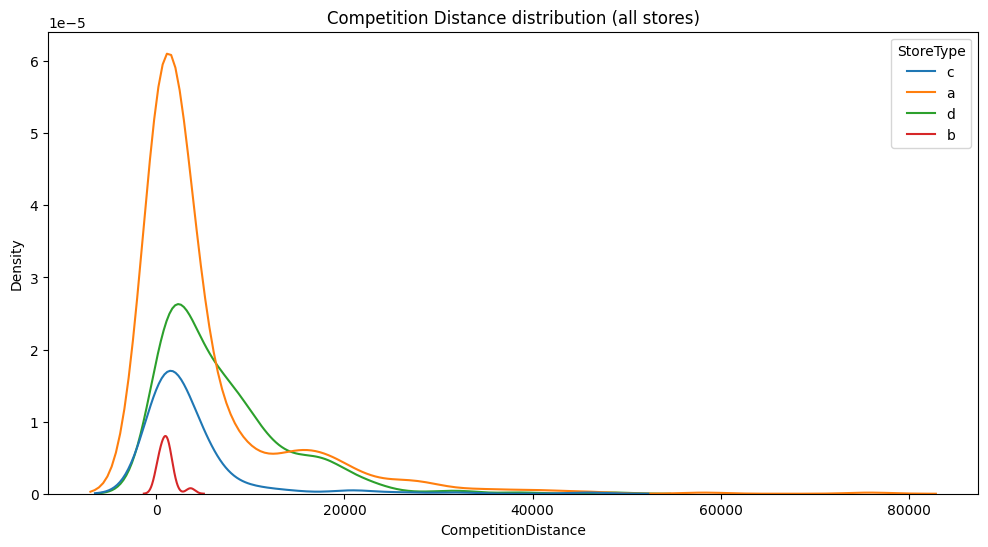

In [90]:
avg_comp_dist = train[
    ["Store", "CompetitionDistance", "StoreType"]
].groupby("Store").agg({"CompetitionDistance": "mean", "StoreType": "max"})

fig, ax = plt.subplots(figsize=(12,6))
sns.kdeplot(data=avg_comp_dist, x="CompetitionDistance", hue="StoreType")
ax.set(title="Competition Distance distribution (all stores)");

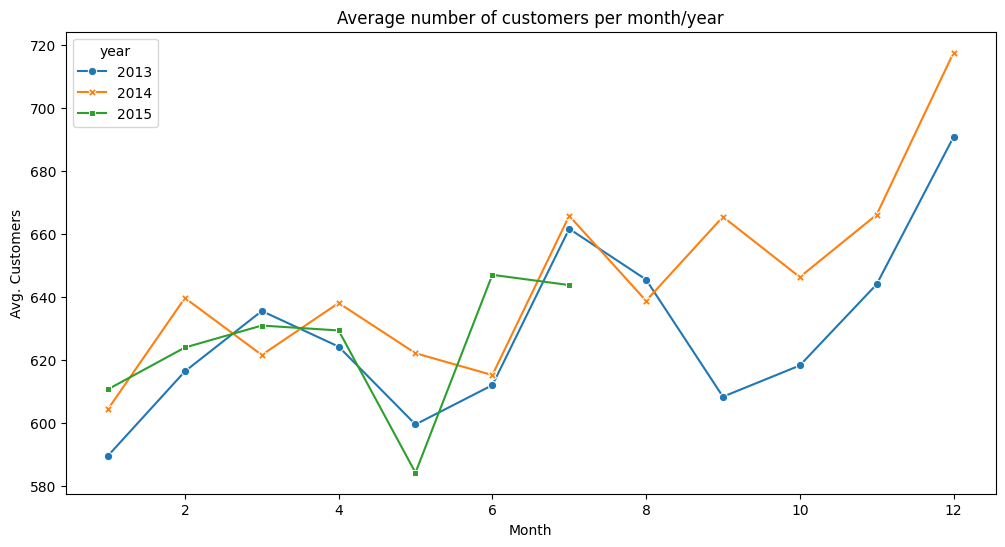

In [103]:
count_customers = train.groupby(["year","month"])["Customers"].mean().to_frame("avg_Customers")
count_customers.reset_index(inplace=True)

fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(
    data=count_customers,
    x="month",
    y="avg_Customers",
    hue="year",
    palette="tab10",
    style="year",
    markers=True,dashes=False
)
ax.set(title="Average number of customers per month/year",
        xlabel="Month", ylabel="Avg. Customers");

In [181]:
stores_with_later_comps = train[
    train["CompetitionOpenSinceYear"] > train["year"]]["Store"].unique()

print("Store IDs with competitor that opened later:")
stores_with_later_comps

Store IDs with competitor that opened later:


array([   5,  103,  131,  170,  185,  197,  225,  261,  269,  286,  301,
        304,  326,  403,  496,  550,  563,  595,  630,  688,  718,  770,
        837,  839,  918,  944,  996, 1013, 1020, 1034, 1044, 1053, 1072,
       1085,  137,  518,  859,  902,    8,   14,   28,   30,   37,   45,
         52,   54,   57,   84,   95,  120,  126,  138,  166,  169,  189,
        213,  249,  264,  266,  268,  270,  275,  276,  318,  336,  361,
        369,  386,  391,  413,  416,  423,  428,  449,  488,  506,  555,
        556,  585,  599,  601,  604,  629,  635,  646,  653,  677,  683,
        706,  715,  740,  784,  800,  819,  828,  872,  878,  901,  903,
        905,  947,  956,  970,  983,  986, 1019, 1050, 1111])

In [ ]:
# Check the impact in Sales after a competitor opens a store near to a Rossmann one

impacts_sales_stores = pd.DataFrame()

for store_id in stores_with_later_comps:
    store_x = train[train["Store"] == store_id].sort_values("Date").copy()
    store_x = store_x.groupby(["year", "month"]).agg({
        "Sales":"mean",
        "days_to_competitor": "max",
        "CompetitionDistance": "min",
        "Customers": "mean"
    })
    store_x.reset_index(inplace=True)

    store_x["year-month"] = store_x["year"].astype(str) +"-"+ store_x["month"].astype(str)

    pos_dates = store_x[store_x["days_to_competitor"] >= 0]
    #mean_customers = pos_dates["Customers"].values[0]
    min_dist = pos_dates["CompetitionDistance"].values[0]
    idx_turning_point = pos_dates.index.values[0]
    turning_point = pos_dates["year-month"].values[0]

    before_openning_sales = store_x[store_x.index < idx_turning_point].tail(4)
    after_openning_sales = store_x[store_x.index >= idx_turning_point].head(4)

    mean_before = before_openning_sales["Sales"].mean()
    mean_after = after_openning_sales["Sales"].mean()
    mean_customers_before = before_openning_sales["Customers"].mean()
    mean_customers_after = after_openning_sales["Customers"].mean()

    impact_sales = pd.DataFrame([{
        "mean_sales_4m_before": mean_before,
        "mean_sales_4m_after": mean_after,
    }], index=[store_id])

    impact_sales["impact.pct"] = impact_sales.pct_change(axis="columns", periods=1).iloc[0,-1] * 100
    impact_sales.insert(2, "abs_mean_difference", abs(mean_after - mean_before))
    impact_sales.insert(0, "CompetitionDistance", min_dist)
    impact_sales.insert(1, "mean_customers_4m_before", mean_customers_before)
    impact_sales.insert(2, "mean_customers_4m_after", mean_customers_after)

    impact_sales["impact.customers.pct"] = impact_sales[["mean_customers_4m_before", "mean_customers_4m_after"]].pct_change(axis="columns").iloc[:,-1] * 100

    impact_sales = impact_sales.round(2)
    impact_sales.index.name = "Store"

    impacts_sales_stores = pd.concat([impacts_sales_stores, impact_sales])

impacts_sales_stores.head()

,CompetitionDistance,mean_customers_4m_before,mean_customers_4m_after,mean_sales_4m_before,mean_sales_4m_after,abs_mean_difference,impact.pct,impact.customers.pct
Store,,,,,,,,
5,29910.0,456.48,437.27,4130.31,3828.64,301.67,-7.30,-4.21
103,5210.0,370.47,366.56,4138.41,4096.09,42.32,-1.02,-1.06
131,920.0,430.42,426.98,4106.41,4134.49,28.08,0.68,-0.80
170,1070.0,470.27,434.55,4331.58,4086.85,244.73,-5.65,-7.60
185,1860.0,480.12,474.24,6484.72,6465.13,19.58,-0.30,-1.23


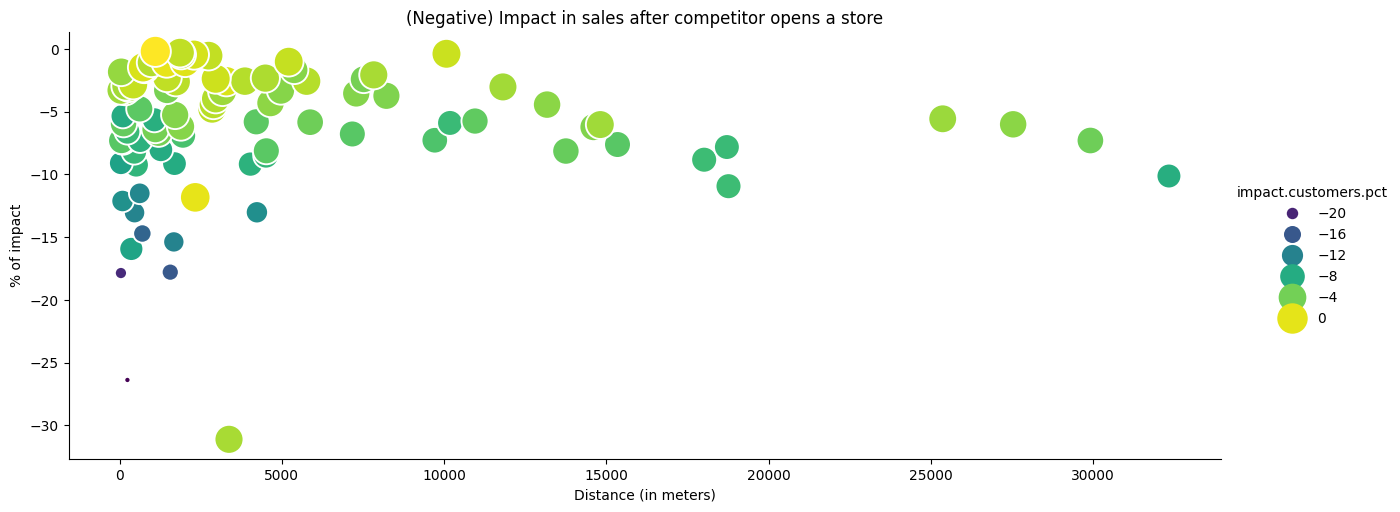

In [290]:
neg_impact_sales = impacts_sales_stores[impacts_sales_stores["impact.pct"] < 0].sort_values("impact.pct")

#fig, ax = plt.subplots(figsize=(12,6))
ax = sns.relplot(data=neg_impact_sales, x="CompetitionDistance", y="impact.pct",
                size="impact.customers.pct", hue="impact.customers.pct", palette="viridis",
                sizes=(20, 500), height=5, aspect=2.5)
ax.set(title="(Negative) Impact in sales after competitor opens a store",#
    xlabel="Distance (in meters)", ylabel="% of impact");

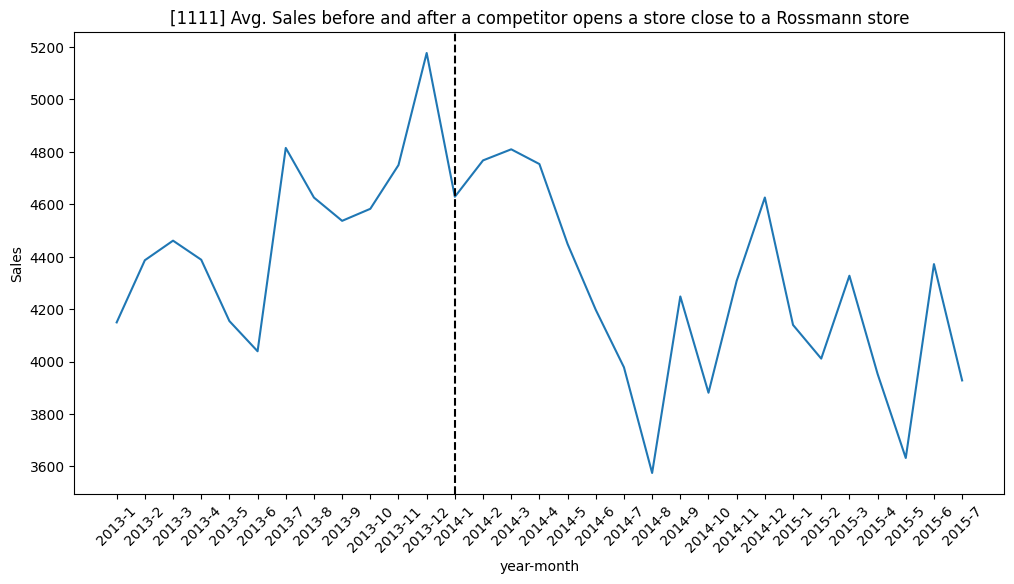

In [315]:
# Pick a store and check sales before and after a competitor opens
later_store_id = 1111 #random.choice(stores_with_later_comps)
store_x = train[train["Store"] == later_store_id].sort_values("Date").copy()
store_x = store_x.groupby(["year", "month"]).agg({
    "Sales":"mean",
    "days_to_competitor": "max",
    "CompetitionDistance": "min"
})
store_x.reset_index(inplace=True)

store_x["year-month"] = store_x["year"].astype(str) +"-"+ store_x["month"].astype(str)

pos_dates = store_x[store_x["days_to_competitor"] >= 0]
idx_turning_point = pos_dates.index.values[0]
turning_point = pos_dates["year-month"].values[0]

before_openning_sales = store_x[store_x.index < idx_turning_point].tail(4)
after_openning_sales = store_x[store_x.index >= idx_turning_point].head(4)

fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(data=store_x, x="year-month", y="Sales", palette="tab10")
plt.xticks(rotation=45)
plt.axvline(turning_point, ls='--', color='black')
ax.set(title=f"[{later_store_id}] Avg. Sales before and after a competitor opens a store close to a Rossmann store");

### Further checks

We would like to check the data so that it requires further preprocessing.

In [299]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 21 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [ ]:
# Checking missing values
df = train[["Date", "Open", "Sales","CompetitionDistance",
            "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear"]]

df[df["CompetitionDistance"].isnull()]

,Date,Open,Sales,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
290,2015-07-31,1,10052,NaN,NaN,NaN
621,2015-07-31,1,6306,NaN,NaN,NaN
878,2015-07-31,1,6000,NaN,NaN,NaN
1405,2015-07-30,1,9030,NaN,NaN,NaN
1736,2015-07-30,1,5412,NaN,NaN,NaN
...,...,...,...,...,...,...
1015601,2013-01-02,1,4080,NaN,NaN,NaN
1015858,2013-01-02,1,3077,NaN,NaN,NaN
1016385,2013-01-01,0,0,NaN,NaN,NaN
1016716,2013-01-01,0,0,NaN,NaN,NaN


In [ ]:
# Filling-in Competitor related features
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(200000)
df["CompetitionOpenSinceMonth"] = df.apply(
    lambda x: x["Date"].month
    if np.isnan(x["CompetitionOpenSinceMonth"])
    else x["CompetitionOpenSinceMonth"], axis=1
)
df["CompetitionOpenSinceYear"] = df.apply(
    lambda x: x["Date"].year
    if np.isnan(x["CompetitionOpenSinceYear"])
    else x["CompetitionOpenSinceYear"], axis=1
)

In [326]:
df.loc[[260, 290, 621, 878]]

,Date,Open,Sales,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
260,2015-07-31,1,13470,15340.0,4.0,2015.0
290,2015-07-31,1,10052,200000.0,7.0,2015.0
621,2015-07-31,1,6306,200000.0,7.0,2015.0
878,2015-07-31,1,6000,200000.0,7.0,2015.0


**Insights**:

- Number of unique stores: **1115**
- The number of records per store varies from **758 to 942 records**.
- **Daily** granularity, **from 2013 to 2015**.
- Daily **average sales** is **6955.51** (when stores are obviusly open, *Open=1*).
- When the store is open, the **number of customers** varies from **240 to 3403**.
- *`CompetitionDistance`* vs `Sales` (by `StoreType`) did not show a clear impact in Sales. This means having a competition close to a Rossmann store did not directly impact in Sales. However, I migh find another way to check that besides plotting them in a scatter plot.
- StoreType **b** shows a higher Average Sales compared to the other store types despite it contains less records. They also contain the highest average in number of customers. This means StoreType **b** might be the larger ones.
- The number of School Holidays for 2013 and 2014 follows the same patter in the 2nd semester. However, the pattern of School holiday in the 1st semester of 2013 shows a different pattern.
- The number of Promos were more aggresivelly in March 2013 and January 2015. In the last four months of 2013, the number of Promos stayed at the same level.
- Found out that about 89 stores had negative impact in sales after a competitor starts its business close to a Rossmann store. For these store, we should create a feature that explains a new competitor arrived.
- Feature `CompetitionDistance` presents missing values. I assume it's because there's no competitor near to those Rossmann stores.
    - For `CompetitionDistance`, let's use a higher value which will probably not affect since a possible competitor is so far (e.g. 200km).
    - For `CompetitionOpenSinceMonth` and `CompetitionOpenSinceYear`, we could use `Date` since we are assuming there's no competitor.
- For now, I will leave features related to `Promo2` out. We might revisit them during the the modeling phase.

___